<a href="https://colab.research.google.com/github/BatoolAshour/PythonCodes/blob/main/HandWrittenDigitRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torchvision
import matplotlib
import numpy as np
import pandas as pd

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor

In [3]:
train_data= datasets.MNIST(
    root= 'data',
    train= True,
    transform=ToTensor(),
    download=True
)
test_data= datasets.MNIST(
    root= 'data',
    train= True,
    transform=ToTensor(),
    download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


In [4]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [5]:
test_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [7]:
test_data.data.shape

torch.Size([60000, 28, 28])

In [8]:
train_data.targets.size()

torch.Size([60000])

In [9]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [10]:
from torch.utils.data import DataLoader

loaders= {
    'train': DataLoader(train_data,
                        batch_size=100,
                        shuffle=True,
                        num_workers=1)
    ,
    'test': DataLoader(train_data,
                        batch_size=100,
                        shuffle=True,
                        num_workers=1)
}

In [11]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x7b589b763c80>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7b58a1bb72c0>}

# **1.** **Model Class** **Or** **Architecture**

In [18]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class CNN(nn.Module):

  def __init__(self):
    super(CNN,self).__init__()

    self.conv1 = nn.Conv2d(in_channels=1,out_channels=10, kernel_size=5) #One channel in, 10 Channel out
    self.conv2 = nn.Conv2d(in_channels=10,out_channels=20, kernel_size=5)
    self.conv2_drop = nn.Dropout2d()
    self.fc1= nn.Linear(320,50) #Fully connected Layer
    self.fc2= nn.Linear(50,10)

  def forward(self, x): #Activation
    x= F.relu(F.max_pool2d(self.conv1(x), 2))
    x= F.relu(F.max_pool2d(self.conv2_drop(self.conv2(x)),2))

    #Flatten
    x= x.view(-1,320)

    x= F.relu(self.fc1(x))
    x= F.dropout(x, training= self.training)
    x= self.fc2(x)

    return F.softmax(x)

# **2. Training Process**

In [34]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model= CNN().to(device)

optimizer= optim.Adam(model.parameters(), lr=0.001)

loss_fn= nn.CrossEntropyLoss()
train_losses = []

def train(epoch):
  model.train()
  for bach_idx, (data,target) in enumerate(loaders['train']):
    data, target= data.to(device), target.to(device)
    optimizer.zero_grad()
    output= model(data)
    loss= loss_fn(output, target)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if bach_idx % 20 ==0:
      print(f'Train Epoch: {epoch} [{bach_idx *len(data)}/{len(loaders["train"].dataset)}({100.*bach_idx/len(loaders["train"]):0.0f}%)]\t{loss.item():.6f}')

def test():
  model.eval()

  test_loss=0
  correct=0

  with torch.no_grad():
    for data, target in loaders['test']:
      data, target= data.to(device), target.to(device)
      output= model(data)
      test_loss+= loss_fn(output, target).item()
      pred= output.argmax(dim=1, keepdim=True)
      correct+= pred.eq(target.view_as(pred)).sum().item()

  test_loss/= len(loaders['test'].dataset)
  print(f'\nTest Set: Average Loss: {test_loss:.4f}, Accuracy: {correct}/{len(loaders["test"].dataset)}({100. * correct / len(loaders["test"].dataset):.0f}%\n)')

In [35]:
for epoch in range(1,11):
  train(epoch)
  test()

/tmp/ipython-input-905984271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


Train Epoch: 1 [0/60000(0%)]	2.301712
Train Epoch: 1 [2000/60000(3%)]	2.286760
Train Epoch: 1 [4000/60000(7%)]	2.110889
Train Epoch: 1 [6000/60000(10%)]	2.016474
Train Epoch: 1 [8000/60000(13%)]	1.889087
Train Epoch: 1 [10000/60000(17%)]	1.880506
Train Epoch: 1 [12000/60000(20%)]	1.887755
Train Epoch: 1 [14000/60000(23%)]	1.763690
Train Epoch: 1 [16000/60000(27%)]	1.755250
Train Epoch: 1 [18000/60000(30%)]	1.692569
Train Epoch: 1 [20000/60000(33%)]	1.665349
Train Epoch: 1 [22000/60000(37%)]	1.720380
Train Epoch: 1 [24000/60000(40%)]	1.687720
Train Epoch: 1 [26000/60000(43%)]	1.681841
Train Epoch: 1 [28000/60000(47%)]	1.619192
Train Epoch: 1 [30000/60000(50%)]	1.674597
Train Epoch: 1 [32000/60000(53%)]	1.586641
Train Epoch: 1 [34000/60000(57%)]	1.652596
Train Epoch: 1 [36000/60000(60%)]	1.616063
Train Epoch: 1 [38000/60000(63%)]	1.595723
Train Epoch: 1 [40000/60000(67%)]	1.686119
Train Epoch: 1 [42000/60000(70%)]	1.586307
Train Epoch: 1 [44000/60000(73%)]	1.632222
Train Epoch: 1 [46000/

Prediction: 3


/tmp/ipython-input-905984271.py:27: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return F.softmax(x)


<function matplotlib.pyplot.show(close=None, block=None)>

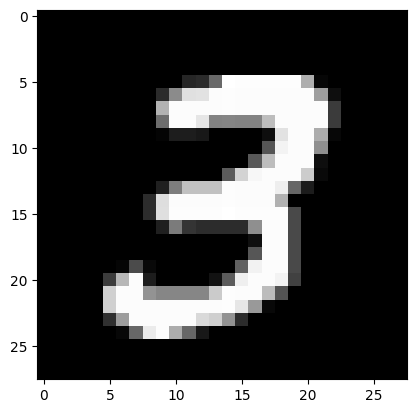

In [36]:
import matplotlib.pyplot as plt

model.eval()

data,target= test_data[7]

data= data.unsqueeze(0).to(device)

output= model(data)

prediction= output.argmax(dim=1, keepdim=True).item()

print(f'Prediction: {prediction}')
image= data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image, cmap='gray')

plt.show
